# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [3]:
df_california = pd.read_csv('california_dataset.csv')

In [4]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

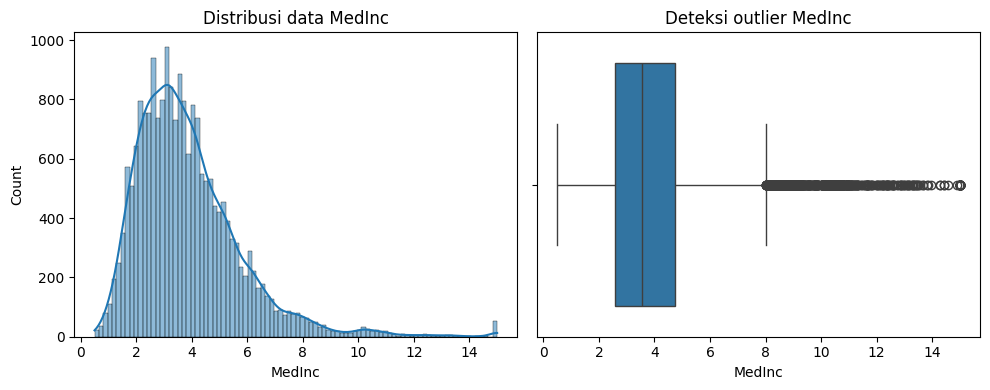

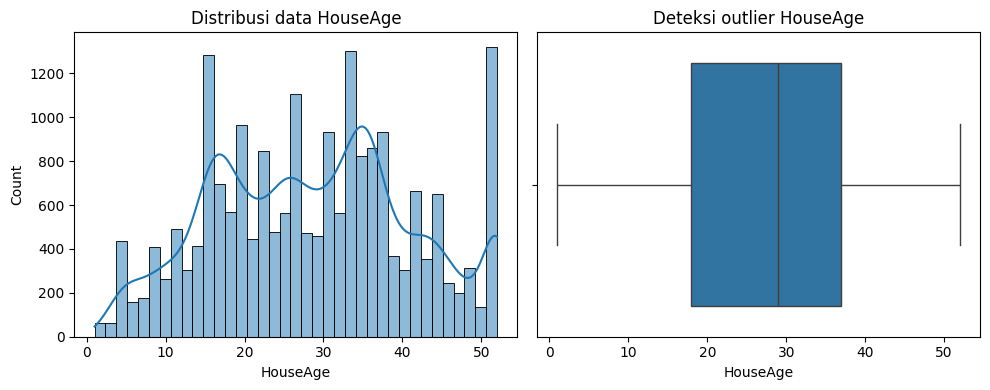

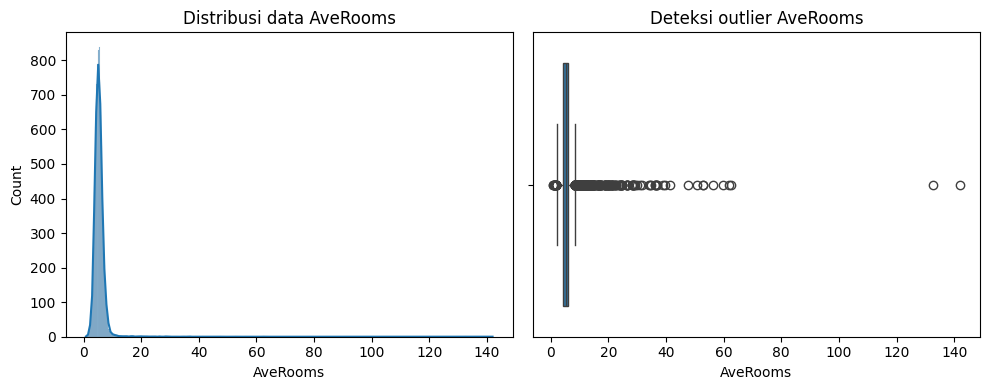

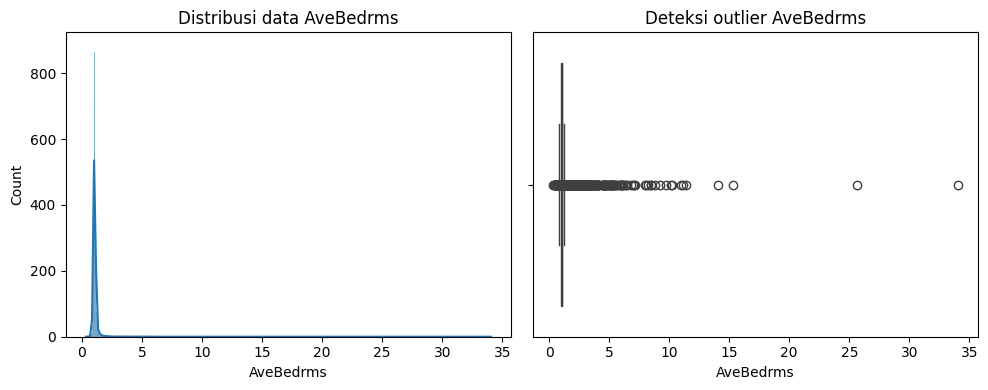

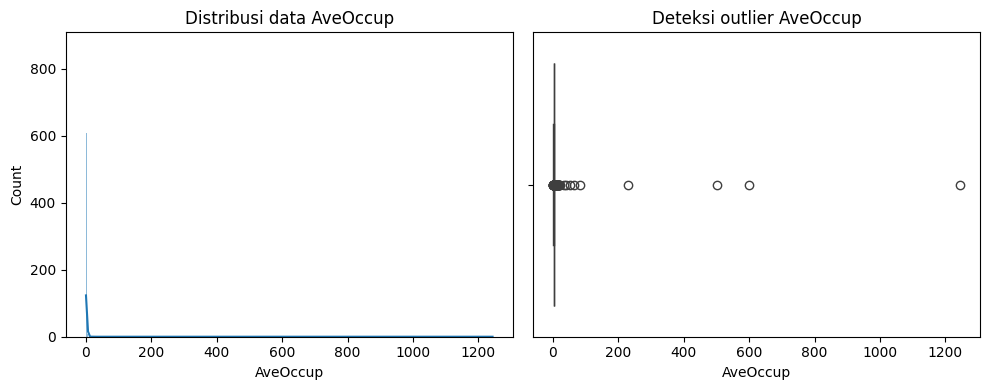

In [50]:
# daftar fitur yang ingin dianalisis
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# looping untuk menampilkan distribusi dan outlier
for fitur_item in kolom_kolom:

    plt.figure(figsize=(10,4))

    # Plot distribusi data (histogram + KDE)
    plt.subplot(1,2,1)
    sns.histplot(df_california[fitur_item], kde=True)
    plt.title('Distribusi data ' + fitur_item)

    # Plot untuk melihat outlier (boxplot)
    plt.subplot(1,2,2)
    sns.boxplot(x=df_california[fitur_item])
    plt.title('Deteksi outlier ' + fitur_item)

    # menampilkan kedua plot
    plt.tight_layout()
    plt.show()

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

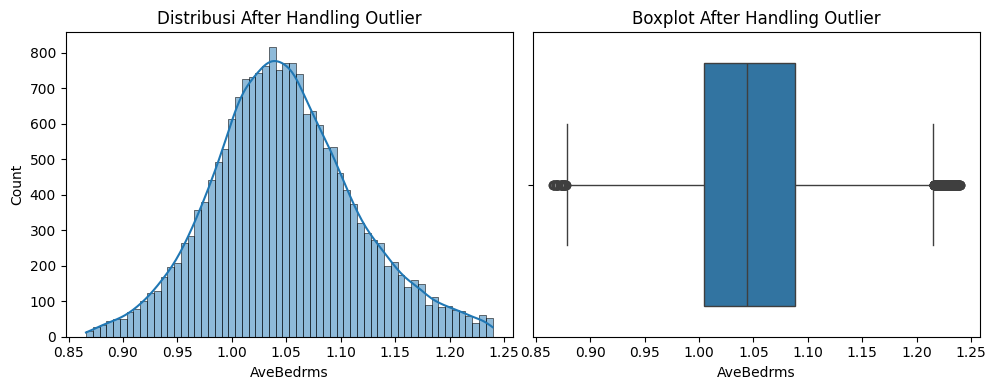

In [51]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali

# Membaca dataset
df_california = pd.read_csv('california_dataset.csv')

# Pilih kolom yang ingin di-handle
kolom = 'AveBedrms'

# Menghitung Q1 dan Q3
Q1 = df_california[kolom].quantile(0.25)
Q3 = df_california[kolom].quantile(0.75)

# Menghitung IQR
IQR = Q3 - Q1

# Menentukan batas bawah dan atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Menghapus outlier
data_clean = df_california[(df_california[kolom] >= batas_bawah) & (df_california[kolom] <= batas_atas)]


# Membuat figure dengan ukuran 10x4 untuk menampilkan dua plot
plt.figure(figsize=(10,4))

# Subplot pertama
plt.subplot(1,2,1)
sns.histplot(data_clean[kolom], kde=True)
plt.title('Distribusi After Handling Outlier')

# Subplot kedua
plt.subplot(1,2,2)
sns.boxplot(x=data_clean[kolom])
plt.title('Boxplot After Handling Outlier')

# Menampilkan plot
plt.tight_layout()
plt.show()

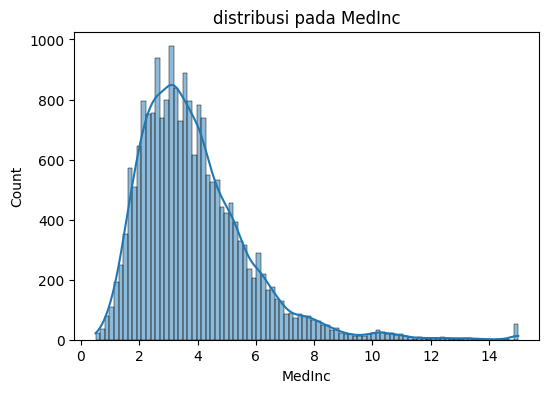

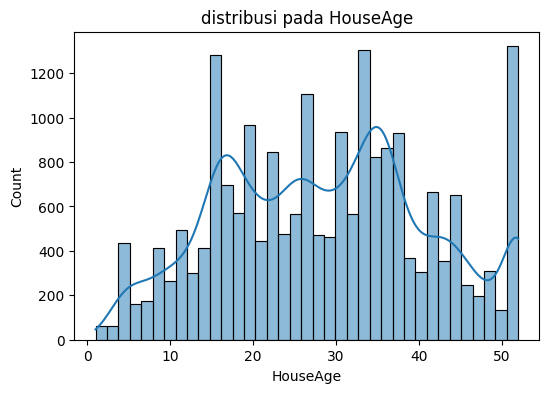

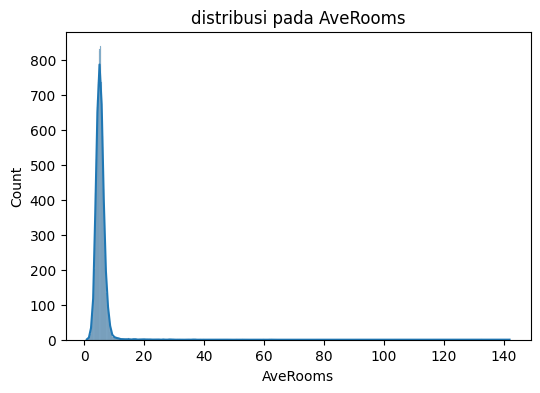

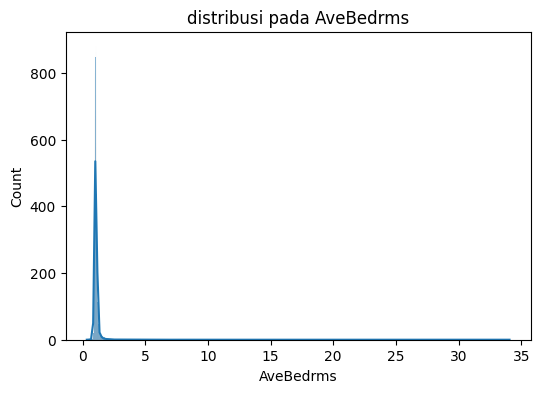

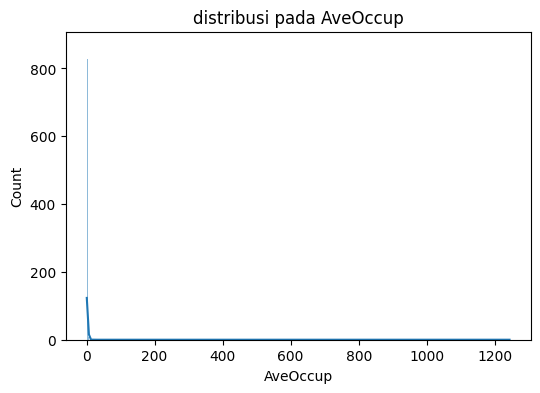

In [33]:
# Melakukan loop untuk mengecek distribusi tiap kolom


# Membaca dataset
df_california = pd.read_csv('california_dataset.csv')

# bagian yang ingin dicek
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# melakukan Loop untuk melihat distribusi tiap kolom
for kolom in kolom_kolom:
    plt.figure(figsize=(6,4))
    sns.histplot(df_california[kolom], kde=True)
    plt.title('distribusi pada ' + kolom)
    plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [14]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [34]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [52]:
# Handling missing value pada kolom Headquarters

train_data, test_data = train_test_split(df_company, test_size=0.2, random_state=42)

null_count = train_data['Headquarters'].isnull().sum()
jumlah_data = len(train_data)

null_percentage = (null_count / jumlah_data) * 100

print("Jumlah missing value:", null_count)
print("Persentase missing value:", null_percentage, "%")

print("Cek missing (True = missing):")
print(train_data['Headquarters'].isnull())

if null_percentage > 20:
    print("Kolom Headquarters di-drop karena missing value > 20%")
    train_data = train_data.drop(columns=['Headquarters'])
else:
    print("Kolom tetap digunakan karena missing value <= 20%")

    nilai_mode = train_data['Headquarters'].mode()[0]
    train_data['Headquarters'] = train_data['Headquarters'].fillna(nilai_mode)

Jumlah missing value: 0
Persentase missing value: 0.0 %
Cek missing (True = missing):
480    False
605    False
61     False
145    False
353    False
29     False
163    False
321    False
215    False
655    False
405    False
174    False
431    False
556    False
449    False
340    False
606    False
390    False
209    False
631    False
601    False
588    False
549    False
485    False
434    False
382    False
104    False
114    False
603    False
609    False
470    False
542    False
7      False
89     False
507    False
356    False
493    False
349    False
341    False
234    False
140    False
522    False
43     False
42     False
73     False
167    False
227    False
586    False
66     False
11     False
593    False
547    False
530    False
248    False
335    False
329    False
274    False
578    False
177    False
447    False
412    False
83     False
421    False
332    False
617    False
79     False
23     False
249    False
357    False
213    False
260 

# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [22]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [56]:
#Splitting terlebih dahulu

from sklearn.model_selection import train_test_split

train, test = train_test_split(df_churn, test_size=0.2, random_state=42)

print("Jumlah data pada train:", len(train))
print("Jumlah data pada test:", len(test))

Jumlah data pada train: 5634
Jumlah data pada test: 1409


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [57]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder


In [58]:
#Splitting
kolom = ['StreamingMovies','StreamingTV','TechSupport','DeviceProtection','OnlineBackup','OnlineSecurity',
        'MultipleLines']

train[kolom].head(15)

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
2142,Yes,No,No,Yes,No,Yes,No
1623,Yes,Yes,No,No,Yes,No,Yes
6074,No,No,No,No,No,No,No phone service
1362,No,No,No,No,No,No,No
6754,No,No,Yes,No,Yes,Yes,Yes
1212,No,No,No,No,No,No,No
2722,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No
4006,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No
6791,No,Yes,No,Yes,No,No,No phone service
5466,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No


In [59]:
kolom = ['StreamingMovies','StreamingTV','TechSupport',
         'DeviceProtection','OnlineBackup','OnlineSecurity',
         'MultipleLines']

for k in kolom:
    train[k] = train[k].replace({'No internet Service': 'No'})

for k in kolom:
    print(k)
    print(train[k].value_counts())
    print()

StreamingMovies
StreamingMovies
No                     2223
Yes                    2197
No internet service    1214
Name: count, dtype: int64

StreamingTV
StreamingTV
No                     2239
Yes                    2181
No internet service    1214
Name: count, dtype: int64

TechSupport
TechSupport
No                     2791
Yes                    1629
No internet service    1214
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     2489
Yes                    1931
No internet service    1214
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     2448
Yes                    1972
No internet service    1214
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     2810
Yes                    1610
No internet service    1214
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  2685
Yes                 2397
No phone service     552
Name: count, dtype: int64



In [60]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for k in kolom:
    train[k] = le.fit_transform(train[k])

train[kolom].head(10)

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
2142,2,0,0,2,0,2,0
1623,2,2,0,0,2,0,2
6074,0,0,0,0,0,0,1
1362,0,0,0,0,0,0,0
6754,0,0,2,0,2,2,2
1212,0,0,0,0,0,0,0
2722,1,1,1,1,1,1,0
4006,1,1,1,1,1,1,0
6791,0,2,0,2,0,0,1
5466,1,1,1,1,1,1,0


## Selesai :)